In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt #for visualization
from sympy import im, symbols, Eq, solve, Matrix, diff
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

/home/mary/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


0.0007999992


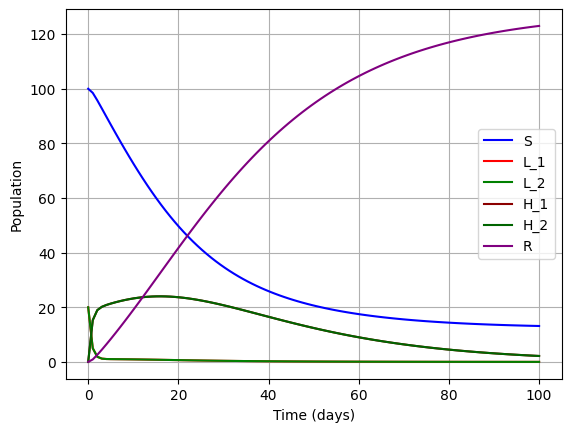

Text(0, 0.5, 'Proportion')

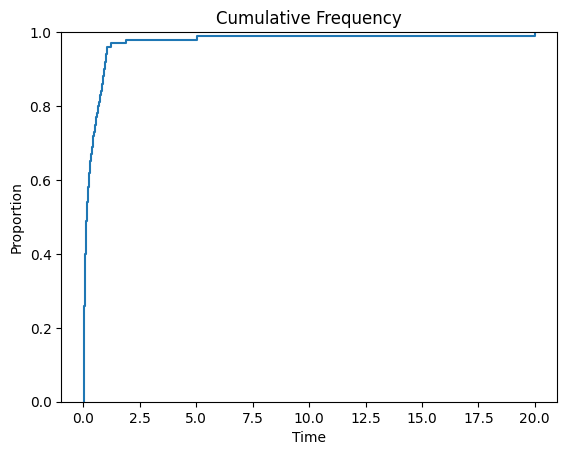

In [37]:
#set up compartmental model
Lambda = .01
mu = 0.0000333333 #1/lifespan of person
#infection rates
beta_1 = 0.24/(Lambda/mu)
beta_2 = 1/(Lambda/mu)
print(beta_1)
#eta_1 = 0
#eta_2 = 0

#progression rates
alpha_1 = 1.46
alpha_2 = 1.46
#alpha = 1

#competition: w = weight, relative competitive advantage of both strains + probability of being infected with the other

w_1 = beta_1*(alpha_1/(alpha_1 + alpha_2))
w_2 = beta_2*(alpha_2/(alpha_1 + alpha_2))

#recovery rates
gamma_1 = (1/21)
gamma_2 = (1/210)


# we have removed the L_12 compartment, and instead have people who move directly from L_1 or L_2 to H_1 or H_2
def model(t, state):
    S, L_1, L_2, H_1, H_2, R = state
    dSdt = Lambda - beta_1*S*H_1 - beta_2*S*H_2 - mu*S
    dL_1dt = beta_1*S*H_1 - w_2*L_1*H_2 - alpha_1*L_1 - mu*L_1
    dL_2dt = beta_2*S*H_2 - w_1*L_2*H_1 - alpha_2*L_2 - mu*L_2
    dH_1dt = alpha_1*L_1 + w_1*L_2*H_1 - gamma_1*H_1 - mu*H_1 #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
    dH_2dt = alpha_2*L_2 + w_2*L_1*H_2 - gamma_2*H_2 - mu*H_2  #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
    dRdt = gamma_1*H_1 + gamma_2*H_2 - mu*R
    return [dSdt, dL_1dt, dL_2dt, dH_1dt, dH_2dt, dRdt]

t_span = (0, 100)
initial = (100, 20, 20, 0, 0, 0)

t_evaluate = np.linspace(0, 100, 100)

sol = solve_ivp(fun = model, t_span = t_span, y0 = initial, method = 'RK45', t_eval = t_evaluate)


plt.plot(sol.t, sol.y[0], label='S', color='blue')
plt.plot(sol.t, sol.y[1], label='L_1', color='red')
plt.plot(sol.t, sol.y[2], label='L_2', color='green')
#plt.plot(sol.t, sol.y[3], label='L_12', color='orange')
plt.plot(sol.t, sol.y[3], label='H_1', color='darkred')
plt.plot(sol.t, sol.y[4], label='H_2', color='darkgreen')
plt.plot(sol.t, sol.y[5], label='R', color='purple')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.show()

data = sol.y[2]
fig, ax = plt.subplots()

# Plot the exact cumulative curve
ax.ecdf(data, label="Cumulative Incidence")

ax.set_title("Cumulative Frequency")
ax.set_xlabel("Time")
ax.set_ylabel("Proportion")

#print(sol.y[1])
#print(sol.y[3])

In [12]:
#calculate R0
#use the constants from the time series in above cells

S = symbols('S')
L_1 = symbols('L_1')
L_2 = symbols('L_2')
H_1 = symbols('H_1')
H_2 = symbols('H_2')
R = symbols('R')

dSdt = Lambda - beta_1*S*H_1 - beta_2*S*H_2 - mu*S
dL_1dt = beta_1*S*H_1 - w_2*L_1*H_2 - alpha_1*L_1 - mu*L_1
dL_2dt = beta_2*S*H_2 - w_1*L_2*H_1 - alpha_2*L_2 - mu*L_2
dH_1dt = alpha_1*L_1 + w_1*L_2*H_1 - gamma_1*H_1 - mu*H_1 #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
dH_2dt = alpha_2*L_2 + w_2*L_1*H_2 - gamma_2*H_2 - mu*H_2  #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
dRdt = gamma_1*H_1 + gamma_2*H_2 - mu*R


fL1 = beta_1 * S * H_1
fL2 = beta_2 * S * H_2
#fL12 = eta_2 * L_1 * H_2 + eta_1 * L_2 * H_1
fH1 = 0 # w_1 * L_2 * H_1
fH2 = 0 #w_2 * L_1 * H_2


vL1 = w_2 * L_1 * H_2 + alpha_1 * L_1 + mu * L_1
vL2 = w_1 * L_2 * H_1 + alpha_2 * L_2 + mu * L_2
#vL12 = alpha * c_1 * L_12 + alpha * c_2 * L_12 + mu * L_12
vH1 = gamma_1 * H_1 + mu * H_1 - alpha_1 * L_1 - w_1 * L_2 * H_1
vH2 = gamma_2 * H_2 + mu * H_2 - alpha_2 * L_2 - w_2 * L_1 * H_2

f = Matrix([fL1, fL2, fH1, fH2])
v = Matrix([vL1, vL2, vH1, vH2])

variables = Matrix([L_1, L_2, H_1, H_2])
dfe = {S: Lambda/ mu, L_1: 0, L_2: 0, H_1: 0, H_2: 0}


F_dfe = f.jacobian(variables).subs(dfe)
V_dfe = v.jacobian(variables).subs(dfe)


Vinv = V_dfe.inv()

#F = F.subs(dfe)
#Vinv = Vinv.subs(dfe)

ngm = F_dfe*Vinv
#print(ngm)

eigs = np.linalg.eigvals(np.array(ngm.tolist(), dtype=float))
R0 = np.max(eigs)


print("R0:", R0)

R0: 12.489306873353042


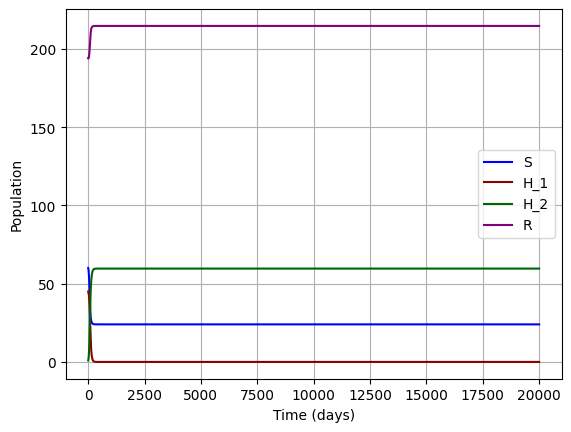

[4.50000000e+01 4.40045675e+01 4.37451188e+01 ... 7.34657662e-07
 1.05716335e-06 7.02543745e-07]


In [10]:
#set up compartmental model
Lambda = .01
mu = 0.0000333333 #1/lifespan of person
#infection rates
beta_1 = 0.24/(Lambda/mu)
beta_2 = 0.5/(Lambda/mu)
#eta_1 = 0
#eta_2 = 0
C_1 = 1/beta_1
C_2 = 1/beta_2

#progression rates
alpha_1 = 2
alpha_2 = 1.46
#alpha = 1

#competition: w = weight, relative competitive advantage of both strains + probability of being infected with the other
c_1 = 0.5
c_2 = 1-c_1
w_1 = 0 #beta_1*c_1 #(alpha_1/(alpha_1 + alpha_2))
w_2 = 0 #beta_2*c_2 #(alpha_2/(alpha_1 + alpha_2))

#recovery rates
gamma_1 = 1/21
gamma_2 = 1/25

iota = 1/90

# we have removed the L_12 compartment, and instead have people who move directly from L_1 or L_2 to H_1 or H_2
# def model(t, state):
#     S, L_1, L_2, H_1, H_2, R = state
#     dSdt = Lambda - beta_1*S*H_1 - beta_2*S*H_2 - mu*S + iota*R
#     dL_1dt = beta_1*S*H_1 - w_2*L_1*H_2 - alpha_1*L_1 - mu*L_1
#     dL_2dt = beta_2*S*H_2 - w_1*L_2*H_1 - alpha_2*L_2 - mu*L_2
#     dH_1dt = alpha_1*L_1 + w_1*L_2*H_1 - gamma_1*H_1 - mu*H_1 #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
#     dH_2dt = alpha_2*L_2 + w_2*L_1*H_2 - gamma_2*H_2 - mu*H_2  #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
#     dRdt = gamma_1*H_1 + gamma_2*H_2 - mu*R - iota*R
#     return [dSdt, dL_1dt, dL_2dt, dH_1dt, dH_2dt, dRdt]

def model(t, state):
    S, L_1, L_2, H_1, H_2, R = state
    dSdt = - beta_1*S*H_1 - beta_2*S*H_2 + iota*R
    #dSdt = - beta_1*S/(1+C_1*(H_1**2)) - beta_2*S/(1+C_2*(H_2**2)) + iota*R
    dL_1dt = beta_1*S*H_1 - w_2*L_1*H_2 - alpha_1*L_1
    #dL_1dt = beta_1*S/(1+C_1*(H_1**2)) - w_2*L_1*H_2 - alpha_1*L_1
    dL_2dt = beta_2*S*H_2 - w_1*L_2*H_1 - alpha_2*L_2
    #dL_2dt = beta_2*S/(1+C_2*(H_2**2)) - w_1*L_2*H_1 - alpha_2*L_2
    dH_1dt = alpha_1*L_1 + w_1*L_2*H_1 - gamma_1*H_1 #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
    dH_2dt = alpha_2*L_2 + w_2*L_1*H_2 - gamma_2*H_2 #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
    dRdt = gamma_1*H_1 + gamma_2*H_2 - iota*R
    return [dSdt, dL_1dt, dL_2dt, dH_1dt, dH_2dt, dRdt]

t_span = (0, 20000)
initial = (60, 0, 0, 45, 1, 194)

t_evaluate = np.linspace(0, 20000, 2000)

sol = solve_ivp(fun = model, t_span = t_span, y0 = initial, method = 'RK45', t_eval = t_evaluate)


plt.plot(sol.t, sol.y[0], label='S', color='blue')
#plt.plot(sol.t, sol.y[1], label='L_1', color='red')
#plt.plot(sol.t, sol.y[2], label='L_2', color='green')
#plt.plot(sol.t, sol.y[3], label='L_12', color='orange')
plt.plot(sol.t, sol.y[3], label='H_1', color='darkred')
plt.plot(sol.t, sol.y[4], label='H_2', color='darkgreen')
plt.plot(sol.t, sol.y[5], label='R', color='purple')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.show()

# data = sol.y[2]
# fig, ax = plt.subplots()

# # Plot the exact cumulative curve
# ax.ecdf(data, label="Cumulative Incidence")

# ax.set_title("Cumulative Frequency")
# ax.set_xlabel("Time")
# ax.set_ylabel("Proportion")

#print(sol.y[1])
print(sol.y[3])

In [11]:
#Calculating actual beta from effective beta values
beta_1_real = beta_1*(alpha_1+alpha_2)/(2*alpha_1 + alpha_2)
print(beta_1_real)

check = (iota - mu)*beta_2 - iota*gamma_2 - (iota - mu)*beta_1 + iota*gamma_1
print(check>0)

0.0005069591999999999
True


In [45]:
S = symbols('S')
L_1 = symbols('L_1')
L_2 = symbols('L_2')
#L_12 = symbols('L_12')
H_1 = symbols('H_1')
H_2 = symbols('H_2')
R = symbols('R')

dSdt = - beta_1*S*H_1 - beta_2*S*H_2 + iota*R
dL_1dt = beta_1*S*H_1 - w_2*L_1*H_2 - alpha_1*L_1
dL_2dt = beta_2*S*H_2 - w_1*L_2*H_1 - alpha_2*L_2
dH_1dt = alpha_1*L_1 + w_1*L_2*H_1 - gamma_1*H_1 #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
dH_2dt = alpha_2*L_2 + w_2*L_1*H_2 - gamma_2*H_2 #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
dRdt = gamma_1*H_1 + gamma_2*H_2 - iota*R


Jac = Matrix([[diff(dSdt, S), diff(dSdt, L_1), diff(dSdt, L_2), diff(dSdt, H_1), diff(dSdt, H_2), diff(dSdt, R)], 
    [diff(dL_1dt, S), diff(dL_1dt, L_1), diff(dL_1dt, L_2), diff(dL_1dt, H_1), diff(dL_1dt, H_2), diff(dL_1dt, R)],
    [diff(dL_2dt, S), diff(dL_2dt, L_1), diff(dL_2dt, L_2), diff(dL_2dt, H_1), diff(dL_2dt, H_2), diff(dL_2dt, R)],
    [diff(dH_1dt, S), diff(dH_1dt, L_1), diff(dH_1dt, L_2), diff(dH_1dt, H_1), diff(dH_1dt, H_2), diff(dH_1dt, R)],
    [diff(dH_2dt, S), diff(dH_2dt, L_1), diff(dH_2dt, L_2), diff(dH_2dt, H_1), diff(dH_2dt, H_2), diff(dH_2dt, R)],
    [diff(dRdt, S), diff(dRdt, L_1), diff(dRdt, L_2), diff(dRdt, H_1), diff(dRdt, H_2), diff(dRdt, R)]])
#print(Jac)
Jac = Jac.subs({S:60, L_1:1, L_2:0, H_1:45, H_2:0, R:194}) #MATLAB calculated steady state values
eigs = Jac.eigenvals()
print(eigs)

{-1.53680429168769 + 4.70594144243905e-66*I: 1, -1.50913072334626 + 4.94825569718379e-66*I: 1, -0.0227996996919488 - 0.0391682589951699*I: 1, -0.0227996996919488 + 0.0391682589951699*I: 1, 0.0116852615686473 + 1.24958128374555e-66*I: 1, 8.12176500699983e-66 - 2.07053606896891e-68*I: 1}


In [19]:
#optimize H_1/H_2 w.r.t parameters--is there an equilibrium where they are both positive?

#assume H_2 positive

from scipy.optimize import minimize

# 1. Define the objective function
def objective(p):
    # Unpack the single parameter array
    Lambda, mu, iota, alpha_1, alpha_2, beta_1, beta_2, gamma_1, gamma_2 = p
    
    # Note: Fixed the typo "bate_1" to "beta_1" below
    num = Lambda * beta_2 * iota + mu * (beta_2 * mu - gamma_2 * iota)
    den = Lambda * beta_1 * iota + mu * (beta_1 * mu - gamma_1 * iota)
    return num / den

# 2. Constraint 1 (Inequality): >= 0
def constraint1(p):
    Lambda, mu, iota, alpha_1, alpha_2, beta_1, beta_2, gamma_1, gamma_2 = p
    return Lambda * beta_1 * alpha_1 / ((gamma_1 + mu) * (alpha_1 + mu) * mu) - 1

# 3. Constraint 2 (Inequality): >= 0
def constraint2(p):
    Lambda, mu, iota, alpha_1, alpha_2, beta_1, beta_2, gamma_1, gamma_2 = p
    return Lambda * beta_2 * alpha_2 / ((gamma_2 + mu) * (alpha_2 + mu) * mu) - 1

# 4. Format constraints as a list of dictionaries
constraints = [
    {'type': 'ineq', 'fun': constraint1},
    {'type': 'ineq', 'fun': constraint2}
]

# 5. Define variable bounds: (min, max) pairs for each variable
bounds = [(1e-12, 10)] * 9

# 6. Run the optimization using COBYLA--SPSQA fails with positive directional derivatives
initial_guess = [0.01, 0.000033333, 1/90, 1.46, 2, 0.0008, 0.0008, 1/21, 1/21]
result = minimize(objective, initial_guess, method='COBYLA', bounds=bounds, constraints=constraints)

print("Status:", result.message)
if result.success:
    print("Optimization successful!")
    # The optimal parameters are stored in the array result.x
    opt_Lambda, opt_mu, opt_iota, opt_alpha_1, opt_alpha_2, opt_beta_1, opt_beta_2, opt_gamma_1, opt_gamma_2 = result.x
    print(f"Optimal beta_1: {opt_beta_1}")
    print(f"Optimal objective value (H_1/H_2): {result.fun}")
else:
    print("Optimization failed.")
    print(result.maxcv)


Status: Did not converge to a solution satisfying the constraints. See `maxcv` for magnitude of violation.
Optimization failed.
0.00042011875375014274
